In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv("../data/ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [11]:
print("Null Hypothesis (H0): There is no difference in conversion rate between the control and treatment groups.")
print("Alternative Hypothesis (H1): There is a difference in conversion rate between the control and treatment groups.")

Null Hypothesis (H0): There is no difference in conversion rate between the control and treatment groups.
Alternative Hypothesis (H1): There is a difference in conversion rate between the control and treatment groups.


In [12]:
mismatch = df[
    ((df["group"] == "treatment") & (df["landing_page"] != "new_page")) |
    ((df["group"] == "control") & (df["landing_page"] != "old_page"))
]

print("Mismatched rows:", mismatch.shape[0])

df_clean = df.drop(mismatch.index)

Mismatched rows: 3893


In [13]:
print("Duplicate users before cleaning:", df_clean["user_id"].duplicated().sum())

df_clean = df_clean.drop_duplicates(subset="user_id")

print("Duplicate users after cleaning:", df_clean["user_id"].duplicated().sum())
print("Cleaned dataset shape:", df_clean.shape)

Duplicate users before cleaning: 1
Duplicate users after cleaning: 0
Cleaned dataset shape: (290584, 5)


In [14]:
conversion_summary = df_clean.groupby("group")["converted"].agg(["mean", "count", "sum"])
conversion_summary.rename(columns={"mean": "conversion_rate"}, inplace=True)
print(conversion_summary)

           conversion_rate   count    sum
group                                    
control           0.120386  145274  17489
treatment         0.118808  145310  17264


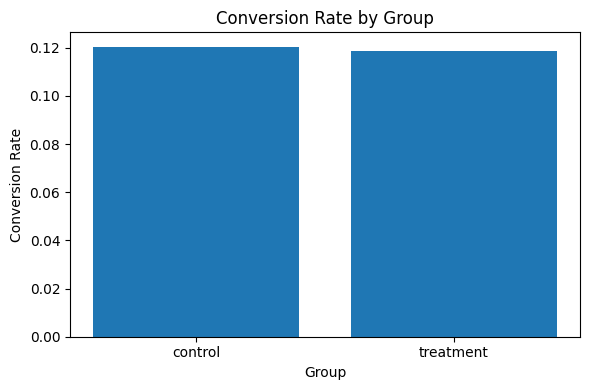

In [15]:
conversion_rates = conversion_summary["conversion_rate"]

plt.figure(figsize=(6, 4))
plt.bar(conversion_rates.index, conversion_rates.values)
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.tight_layout()
plt.savefig("../results/figures/conversion_rate_by_group.png")
plt.show()

In [16]:
control_rate = conversion_summary.loc["control", "conversion_rate"]
treatment_rate = conversion_summary.loc["treatment", "conversion_rate"]

uplift = ((treatment_rate - control_rate) / control_rate) * 100

print(f"Control Conversion Rate: {control_rate:.4f}")
print(f"Treatment Conversion Rate: {treatment_rate:.4f}")
print(f"Uplift: {uplift:.2f}%")

Control Conversion Rate: 0.1204
Treatment Conversion Rate: 0.1188
Uplift: -1.31%


In [17]:
conversions = [
    conversion_summary.loc["control", "sum"],
    conversion_summary.loc["treatment", "sum"]
]

n_obs = [
    conversion_summary.loc["control", "count"],
    conversion_summary.loc["treatment", "count"]
]

z_stat, p_value_z = proportions_ztest(conversions, n_obs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (Z-test): {p_value_z:.4f}")

Z-statistic: 1.3109
P-value (Z-test): 0.1899


In [20]:
contingency_table = pd.crosstab(df_clean["group"], df_clean["converted"])
print("Contingency Table:\n")
print(contingency_table)

chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value (Chi-Square): {p_value_chi2:.4f}")
print(f"Degrees of Freedom: {dof}")

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("\nExpected Frequencies:\n")
print(expected_df)

Contingency Table:

converted       0      1
group                   
control    127785  17489
treatment  128046  17264

Chi-Square Statistic: 1.7036
P-value (Chi-Square): 0.1918
Degrees of Freedom: 1

Expected Frequencies:

converted              0             1
group                                 
control    127899.652748  17374.347252
treatment  127931.347252  17378.652748


In [21]:
ci_low, ci_high = sm.stats.proportion_confint(
    count=np.array(conversions),
    nobs=np.array(n_obs),
    alpha=0.05,
    method="normal"
)

print(f"Control 95% CI: ({ci_low[0]:.4f}, {ci_high[0]:.4f})")
print(f"Treatment 95% CI: ({ci_low[1]:.4f}, {ci_high[1]:.4f})")

Control 95% CI: (0.1187, 0.1221)
Treatment 95% CI: (0.1171, 0.1205)


In [22]:
alpha = 0.05

print("=== Final Interpretation ===")

if p_value_z < alpha:
    print("Z-test: Reject H0 -> statistically significant difference in conversion rates.")
else:
    print("Z-test: Fail to reject H0 -> no statistically significant difference in conversion rates.")

if p_value_chi2 < alpha:
    print("Chi-Square test: Reject H0 -> group assignment and conversion are associated.")
else:
    print("Chi-Square test: Fail to reject H0 -> no significant association between group and conversion.")

=== Final Interpretation ===
Z-test: Fail to reject H0 -> no statistically significant difference in conversion rates.
Chi-Square test: Fail to reject H0 -> no significant association between group and conversion.


In [23]:
if p_value_z < alpha and treatment_rate > control_rate:
    print("Recommendation: The treatment page shows a statistically significant improvement. Consider rollout.")
elif p_value_z < alpha and treatment_rate < control_rate:
    print("Recommendation: The treatment page performs significantly worse. Do not roll out.")
else:
    print("Recommendation: The observed uplift is not statistically significant. Collect more data or iterate on the design.")

Recommendation: The observed uplift is not statistically significant. Collect more data or iterate on the design.


## Hypothesis

**Null Hypothesis (H0):** There is no significant difference in conversion rate between the control and treatment groups.

**Alternative Hypothesis (H1):** There is a significant difference in conversion rate between the control and treatment groups.

To validate the experiment, I used:
- **Two-proportion Z-test** to compare conversion rates directly
- **Chi-Square test** to check whether group assignment and conversion outcome are associated
- **95% Confidence Intervals** to estimate the reliability of the observed rates